# General Instructions
You are only allowed to use numpy and pandas libraries from python (except if it says otherwise) for all this test.

In [1]:
import pandas as pd
import numpy as np

## 1. Variable Simulation with numpy
For this section you are only allowed to use numpy library.

**1.1** Define una función en Python que genere un vector de tamaño (100,1), donde cada elemento $X_t$ sigue una distribución Poisson con parámetro $\lambda = 5$:

$$
X_t \sim \text{Poisson}(5)
$$


Luego:
- Ejecuta la simulación 10,000 veces.
- Calcula la media y la desviación estándar en cada iteración.
- Resume los resultados (mínimo, máximo y promedio).


In [2]:
np.random.seed(42)
def simular_poison(n_iter=10000,n=100,lam=5):
    muestras=np.random.poisson(lam=lam,size=(n_iter,n,1))
    # calcula la media y desviación
    medias=muestras.mean(axis=(1,2))
    desv=muestras.std(axis=(1,2),ddof=1) # ddof=1 → desv. muestral
    
    resumen=pd.DataFrame({
        "iteracion":np.arange(1,n_iter+1),
        "media":medias,
        "desv_std":desv
    })
    
    resultados=pd.DataFrame({
        "medias":[medias.min(),medias.max(),medias.mean()],
        "desv_std":[desv.min(),desv.max(),desv.mean()]},index=["mínimo","máximo","promedio"])
    return resultados,resumen

resultados,resumen=simular_poison()

print("=== Resumen de las 10,000 iteraciones ===")
print(resumen.round(4))
print("\nPrimeras 5 iteraciones:")
print(resultados.head())

=== Resumen de las 10,000 iteraciones ===
      iteracion  media  desv_std
0             1   4.94    2.3818
1             2   4.97    2.0814
2             3   4.98    2.2247
3             4   5.02    2.1880
4             5   4.96    2.5738
...         ...    ...       ...
9995       9996   4.63    2.0134
9996       9997   4.91    2.1839
9997       9998   4.86    2.3528
9998       9999   5.16    1.8680
9999      10000   5.19    1.9781

[10000 rows x 3 columns]

Primeras 5 iteraciones:
            medias  desv_std
mínimo    4.230000  1.626796
máximo    5.900000  2.918142
promedio  5.000198  2.231037


**1.2** Simula dos vectores $( X^{(1)} )$ y $( X^{(2)} )$ de tamaño (100,1), definidos de la siguiente manera:

$$
x^{(1)}_t = 0.5 \, x^{(1)}_{t-1} + \epsilon^{(1)}_t
$$

$$
x^{(2)}_t = 0.5 \, x^{(2)}_{t-1} + \epsilon^{(2)}_t + 0.3 \, x^{(1)}_{t-1}
$$


donde $( \epsilon^{(1)}_t$, $\epsilon^{(2)}_t$ $\sim \mathcal{N}(0,1) )$.  
Considera $( x^{(1)}_0 = x^{(2)}_0 = 0 )$.

Luego:
- Genera ambos vectores respetando la dependencia temporal.
- Grafica ambas series.


In [3]:
import matplotlib.pyplot as plt

np.random.seed(42)

T=100
a1=0.5
a2=0.5
b=0.3

# ε1, ε2 ~ N(0,1)
eps1 = np.random.normal(0, 1, size=T)
eps2 = np.random.normal(0, 1, size=T)

# Vectores de estado
x1 = np.zeros(T + 1)   
x2 = np.zeros(T + 1)

for t in range(1, T + 1):
    x1[t] = a1 * x1[t - 1] + eps1[t - 1]
    x2[t] = a2 * x2[t - 1] + eps2[t - 1] + b * x1[t - 1]
    
x1_vec = x1[1:].reshape(-1, 1)   
x2_vec = x2[1:].reshape(-1, 1)   


df = pd.DataFrame({
    "t":    np.arange(1, T + 1),
    "x1":   x1_vec.flatten(),
    "x2":   x2_vec.flatten()
})

print(df.head(10).round(4))
print("\nEstadísticas descriptivas:")
print(df[["x1", "x2"]].describe().round(4))   


    t      x1      x2
0   1  0.4967 -1.4154
1   2  0.1101 -0.9793
2   3  0.7027 -0.7993
3   4  1.8744 -0.9911
4   5  0.7030 -0.0945
5   6  0.1174  0.5677
6   7  1.6379  2.2053
7   8  1.5864  1.7686
8   9  0.3237  1.6178
9  10  0.7044  0.8315

Estadísticas descriptivas:
             x1        x2
count  100.0000  100.0000
mean    -0.2053   -0.0641
std      1.0267    1.1067
min     -2.6862   -2.4629
25%     -0.8847   -0.7797
50%     -0.1057   -0.1401
75%      0.4525    0.4902
max      1.9676    2.9671


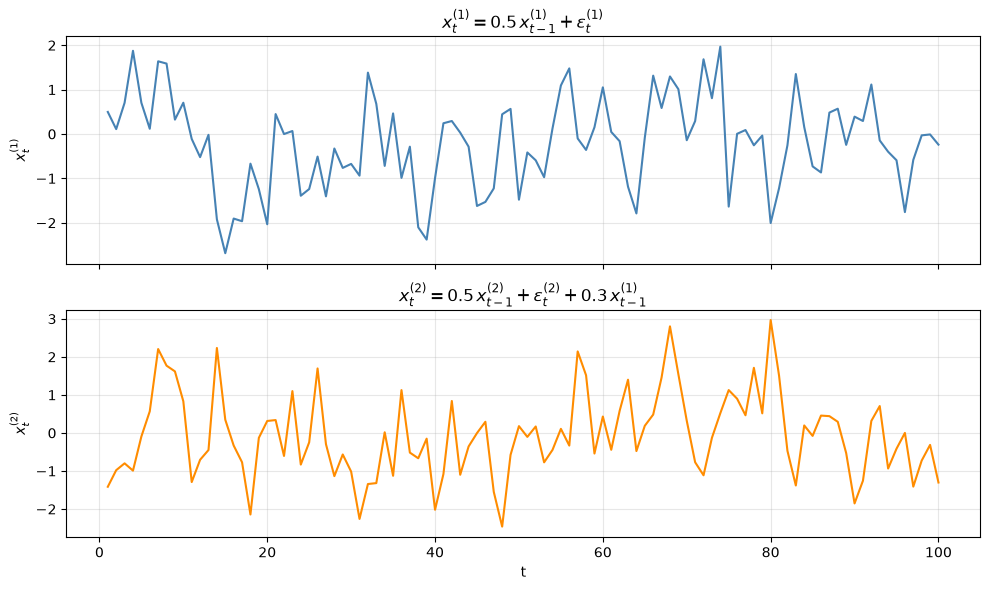

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(df["t"], df["x1"], color="steelblue")
axes[0].set_title(r"$x^{(1)}_t = 0.5\,x^{(1)}_{t-1} + \epsilon^{(1)}_t$")
axes[0].set_ylabel(r"$x^{(1)}_t$")
axes[0].grid(alpha=0.3)

axes[1].plot(df["t"], df["x2"], color="darkorange")
axes[1].set_title(r"$x^{(2)}_t = 0.5\,x^{(2)}_{t-1} + \epsilon^{(2)}_t + 0.3\,x^{(1)}_{t-1}$")
axes[1].set_xlabel("t")
axes[1].set_ylabel(r"$x^{(2)}_t$")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Dataframe manipulation with Pandas

Para esta sección, únicamente puedes utilizar pandas o NumPy.



Se proporcionarán archivos de texto con información de personas identificadas por RENIEC para los años 2014 a 2020 (pob_identificada_YYYY.txt).

Previamente a responder cualquier pregunta, se requiere cargar dichos archivos y consolidarlos en un único DataFrame (df).



In [ ]:
import pandas as pd
from pathlib import Path

carpeta = Path.cwd()   

dfs = []
for anio in range(2014, 2021):
    ruta = carpeta / f"pob_identificada_{anio}.txt"
    df_temp = pd.read_csv(ruta, sep=",")   
    df_temp["anio"] = anio
    dfs.append(df_temp)

df = pd.concat(dfs,ignore_index=True)
print(df.shape)
df.head()

C:\Users\User\AppData\Local\Temp\ipykernel_8048\277385965.py:9: DtypeWarning: Columns (0: UBIGEO_RENIEC, 1: UBIGEO_INEI) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(ruta, sep=",")   # ajusta sep si hace falta
C:\Users\User\AppData\Local\Temp\ipykernel_8048\277385965.py:9: DtypeWarning: Columns (0: DEPARTAMENTO, 1: PROVINCIA, 2: DISTRITO) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(ruta, sep=",")   # ajusta sep si hace falta


(2726214, 12)


,RESIDENCIA,UBIGEO_RENIEC,UBIGEO_INEI,CONTINENTE,PAIS,DEPARTAMENTO,PROVINCIA,DISTRITO,SEXO,EDAD,CANTIDAD,anio
0,Nacional,10101,10101,América,Perú,Amazonas,Chachapoyas,Chachapoyas,Hombre,0,315,2014
1,Nacional,10101,10101,América,Perú,Amazonas,Chachapoyas,Chachapoyas,Hombre,1,337,2014
2,Nacional,10101,10101,América,Perú,Amazonas,Chachapoyas,Chachapoyas,Hombre,2,311,2014
3,Nacional,10101,10101,América,Perú,Amazonas,Chachapoyas,Chachapoyas,Hombre,3,302,2014
4,Nacional,10101,10101,América,Perú,Amazonas,Chachapoyas,Chachapoyas,Hombre,4,276,2014


**2.1.** ¿Cuántos individuos de sexo masculino no residentes fueron identificados entre los años 2018 y 2019?

In [24]:
#print(df["SEXO"].unique())
#print(df["RESIDENCIA"].unique())
#print(df["anio"].unique())

filtro=(
    (df['SEXO']=="Hombre") & (df['RESIDENCIA']=='Extranjero') & (df["anio"].isin([2018, 2019]))
)

total = df.loc[filtro, "CANTIDAD"].sum()
print(f"Individuos hombres no residentes (2018–2019): {total:,.0f}")

Individuos hombres no residentes (2018–2019): 953,841


**2.2.** Considerando los años 2016 a 2018 y el departamento de Arequipa, ¿qué porcentaje de mujeres corresponde a adolescentes?
[Sugerencia: un adolescente es una persona cuya edad se encuentra entre 10 y 19 años]


In [27]:
base = df[
    (df["anio"].between(2016, 2018)) &
    (df["DEPARTAMENTO"] == "Arequipa") &
    (df["SEXO"] == "Mujer")
].copy()

total_mujeres   = base["CANTIDAD"].sum()
mujeres_adolesc = base.loc[base["EDAD"].between(10, 19), "CANTIDAD"].sum()
porcentaje      = mujeres_adolesc / total_mujeres * 100

print(f"Total mujeres Arequipa 2016–2018 : {total_mujeres:,.0f}")
print(f"Mujeres adolescentes (10–19)     : {mujeres_adolesc:,.0f}")
print(f"Porcentaje de adolescentes       : {porcentaje:.2f}%")

Total mujeres Arequipa 2016–2018 : 2,235,817
Mujeres adolescentes (10–19)     : 327,415
Porcentaje de adolescentes       : 14.64%


**2.3.** Considerando el periodo 2014–2020, ¿en qué año la edad promedio de las personas adultas mayores (edad mayor o igual a 60 años) identificadas fue más alta?

In [32]:
adultos = df[df["EDAD"] >= 60].copy()

promedios = (
    adultos.groupby("anio")
           .apply(lambda g: (g["EDAD"] * g["CANTIDAD"]).sum() / g["CANTIDAD"].sum())
           .rename("edad_promedio")
           .to_frame()
)

anio_max = promedios["edad_promedio"].idxmax()
valor_max = promedios.loc[anio_max, "edad_promedio"]

print("Edad promedio de adultos mayores por año:")
print(promedios.round(2))
print(f"\n Año con mayor edad promedio: {anio_max} ({valor_max:.2f} años)")

Edad promedio de adultos mayores por año:
      edad_promedio
anio               
2014          70.47
2015          70.49
2016          70.53
2017          70.57
2018          70.59
2019          70.58
2020          70.54

 Año con mayor edad promedio: 2018 (70.59 años)


## 3. Object Oriented Programming with Python

Desarrolla un programa en Python que implemente una clase `ProfitabilityIndicators` (no se permite el uso de numpy financial).


La clase debe contener:

### I. Atributos de instancia:
- investment
- cash_flow
- assets
- equity
- period

### II. Métodos:

a. **Return on Assets (ROA)** → `get_roa()`

$$
ROA = \frac{\sum_{t=1}^{T} CF_t}{\sum_{t=1}^{T} Assets_t}
$$

b. **Return on Equity (ROE)** → `get_roe()`

$$
ROE = \frac{\sum_{t=1}^{T} CF_t}{\sum_{t=1}^{T} Equity_t}
$$

### III. Ejemplo de uso:

- investment = -150000  
- cash_flow = [25000, 35000, 40000, 50000, 55000]  
- assets = [150000, 130000, 105000, 75000, 40000]  
- equity = [50000, 60000, 70000, 80000, 90000]  
- period = 5  

In [33]:
class FinancialAnalysis:

    def __init__(self, investment, cash_flow, assets, equity, period):
        self.investment = investment
        self.cash_flow  = list(cash_flow)
        self.assets     = list(assets)
        self.equity     = list(equity)
        self.period     = period

    def get_roa(self):
        total_cf     = sum(self.cash_flow)
        total_assets = sum(self.assets)
        return total_cf / total_assets

    def get_roe(self):
        total_cf     = sum(self.cash_flow)
        total_equity = sum(self.equity)
        return total_cf / total_equity
    
    
fa = FinancialAnalysis(
    investment = -150_000,
    cash_flow  = [25_000, 35_000, 40_000, 50_000, 55_000],
    assets     = [150_000, 130_000, 105_000, 75_000, 40_000],
    equity     = [50_000, 60_000, 70_000, 80_000, 90_000],
    period     = 5,
)

roa = fa.get_roa()
roe = fa.get_roe()

print(f"ROA = {roa:.4f}  ({roa*100:.2f}%)")
print(f"ROE = {roe:.4f}  ({roe*100:.2f}%)")
    

ROA = 0.4100  (41.00%)
ROE = 0.5857  (58.57%)


## 4. Machine Learning Algorithms

**Para esta sección, únicamente puedes utilizar pandas, NumPy, scikit-learn y, de ser necesario, matplotlib.**

Se utilizará el dataset *Breast Cancer* para este ejercicio. Cárgalo desde scikit-learn y consólidalo en un DataFrame.

**4.1** Preparación de datos

- Genera un DataFrame con las variables predictoras y la variable objetivo.
- Verifica la existencia de valores nulos.
- Estandariza las variables numéricas.



In [35]:
# pip install scikit-learn

  Using cached scikit_learn-1.9.1-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Using cached scipy-1.18.1-cp313-cp313-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached scikit_learn-1.9.1-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
Using cached scipy-1.18.1-cp313-cp313-win_amd64.whl (36.6 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# Genera un DataFrame con las variables predictoras y la variable objetivo.
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

df = pd.concat([X, y], axis=1)

# Verifica la existencia de valores nulos.
print("Nulos totales:", df.isnull().sum().sum())
print(df.isnull().sum()[df.isnull().sum() > 0])   # imprime vacío si no hay

# Estandariza las variables numéricas.
X = df.drop(columns=["target"])
y = df["target"]

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

df_scaled = pd.concat([X_scaled, y.reset_index(drop=True)], axis=1)

print("\nShape final:", df_scaled.shape)
df_scaled.head()

Nulos totales: 0
Series([], dtype: int64)

Shape final: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015,0
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190,0
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391,0
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010,0
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100,0


**4.2** Modelamiento
- Divide los datos en conjunto de entrenamiento y prueba utilizando una semilla aleatoria de 42.
- Implementa un modelo de regresión logística.
- Entrena el modelo utilizando el conjunto de entrenamiento.


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df_scaled.drop(columns=["target"])
y = df_scaled["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

**4.3** Evaluación del modelo
- Calcula las siguientes métricas sobre el conjunto de prueba:
  - Accuracy
  - Precision
  - Recall
  - F1-score
- Muestra la matriz de confusión.


In [50]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

y_pred = model.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte completo:")
print(classification_report(y_test, y_pred, target_names=["malignant", "benign"]))

Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-score : 0.9861

Matriz de confusión:
[[41  1]
 [ 1 71]]

Reporte completo:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



**4.4.** Análisis

- Interpreta brevemente los resultados obtenidos.
- Identifica cuáles variables tienen mayor impacto en el modelo (coeficientes)


El modelo clasifica correctamente 112 de 114 casos (98.25%).

Solo cometió 2 errores:

1 falso positivo clínico: un tumor maligno clasificado como benigno (fila 0, col 1).

1 falso negativo clínico: un tumor benigno clasificado como maligno (fila 1, col 0).

Precision ≈ Recall ≈ F1 ≈ 0.98–0.99 en ambas clases → el modelo está balanceado, no favorece a ninguna clase.

El macro avg y weighted avg son casi idénticos (0.98) → confirma que el desempeño es uniforme y el dataset no está fuertemente desbalanceado.

            variable  coeficiente  abs_coef
       worst texture    -1.237688  1.237688
        radius error    -1.123324  1.123324
        worst radius    -0.956331  0.956331
worst concave points    -0.942609  0.942609
          worst area    -0.935964  0.935964
      worst symmetry    -0.925231  0.925231
          area error    -0.899034  0.899034
     worst concavity    -0.823374  0.823374
     worst perimeter    -0.767970  0.767970
    worst smoothness    -0.719987  0.719987


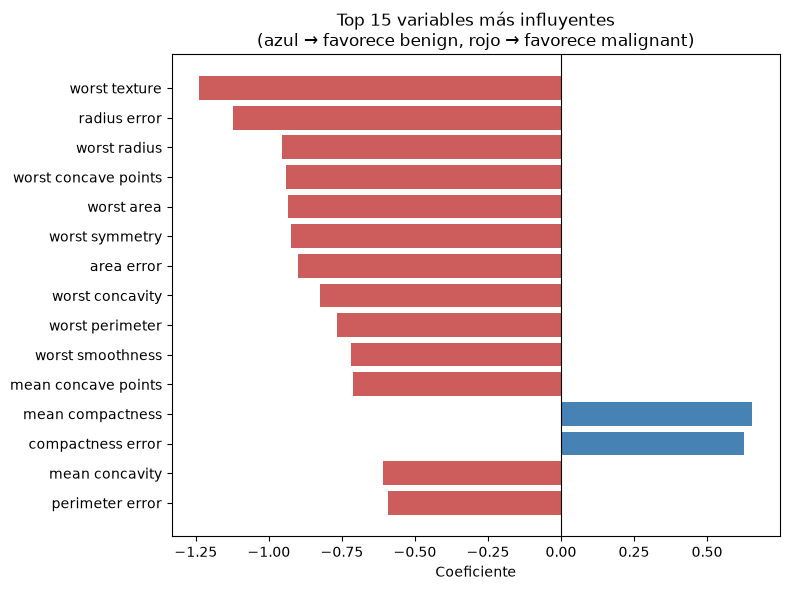

In [57]:
# Coeficientes del modelo
coefs = pd.DataFrame({
    "variable":   X_train.columns,
    "coeficiente": model.coef_[0]
})

# Valor absoluto para ordenar por impacto
coefs["abs_coef"] = coefs["coeficiente"].abs()

# Top 10 variables más influyentes
top10 = coefs.sort_values("abs_coef", ascending=False).head(10)
print(top10.to_string(index=False))


top15 = coefs.sort_values("abs_coef", ascending=False).head(15)

colores = ["steelblue" if c > 0 else "indianred" for c in top15["coeficiente"]]

plt.figure(figsize=(8, 6))
plt.barh(top15["variable"], top15["coeficiente"], color=colores)
plt.axvline(0, color="black", linewidth=0.8)
plt.gca().invert_yaxis()
plt.xlabel("Coeficiente")
plt.title("Top 15 variables más influyentes\n(azul → favorece benign, rojo → favorece malignant)")
plt.tight_layout()
plt.show()

## 5. Missing-data Inputation

**Para esta sección, únicamente puedes utilizar pandas, NumPy, matplotlib/seaborn y scikit-learn.**

El dataset *data_imputation* contiene información básica sobre las características físicas de 500 personas. Sin embargo, existen valores faltantes en la columna *weight*, la cual ha sido identificada como un buen predictor para un modelo específico.

Lee el dataset como un DataFrame de pandas. Para este ejercicio, puedes crear nuevas columnas, pero no debes modificar los nombres de las columnas originales.


**5.1.** Completa los valores faltantes en la columna *weight* y explica el razonamiento detrás de tu decisión.

In [ ]:
import pandas as pd
from pathlib import Path
from sklearn.impute import KNNImputer

carpeta = Path.cwd()  
ruta=carpeta / f"data_inputation.csv"
df=pd.read_csv(ruta,sep='-')

print("Shape:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nNulos por columna:")
print(df.isnull().sum())
print("\nPrimeras filas:")
print(df.head())


Shape: (544, 4)

Columnas: ['Height', 'Weight', 'Age', 'Gender']

Nulos por columna:
Height     0
Weight    82
Age        0
Gender     0
dtype: int64

Primeras filas:
    Height     Weight   Age  Gender
0  151.765  47.825606  63.0    Male
1  139.700  36.485807  63.0  Female
2  136.525        NaN  65.0  Female
3  156.845  53.041914  41.0    Male
4  145.415  41.276872  51.0  Female


In [67]:
corr = df[["Height", "Weight", "Age"]].corr()
corr

,Height,Weight,Age
Height,1.000000,0.944082,0.683689
Weight,0.944082,1.000000,0.678080
Age,0.683689,0.678080,1.000000


In [63]:
# ¿Los nulos dependen del género?
print("Nulos por género:")
print(df.groupby("Gender")["Weight"].apply(lambda s: s.isnull().mean() * 100).round(2))

# ¿Dependen de la altura o edad?
print("\nAltura y edad promedio según si Weight es nulo:")
print(df.groupby(df["Weight"].isnull())[["Height", "Age"]].mean().round(2))

Nulos por género:
Gender
Female    14.98
Male      15.18
Name: Weight, dtype: float64

Altura y edad promedio según si Weight es nulo:
        Height    Age
Weight               
False   137.91  29.40
True    140.26  29.02


In [64]:
df["Gender_num"] = (df["Gender"] == "Male").astype(int)

# Imputación con KNN 
cols = ["Height", "Weight", "Age", "Gender_num"]
imputer = KNNImputer(n_neighbors=5)
df[cols] = imputer.fit_transform(df[cols])

# Verificación
print("Nulos restantes en Weight:", df["Weight"].isnull().sum())
print("\nEstadísticas de Weight después de imputar:")
print(df["Weight"].describe().round(2))

# Comparación antes/después
print(f"\nMedia original (sin nulos): {df['Weight'].mean():.2f}")
print(f"Mediana original:           {df['Weight'].median():.2f}")

# Eliminar columna auxiliar
df = df.drop(columns=["Gender_num"])

Nulos restantes en Weight: 0

Estadísticas de Weight después de imputar:
count    544.00
mean      35.69
std       14.69
min        4.25
25%       22.28
50%       40.35
75%       47.07
max       62.99
Name: Weight, dtype: float64

Media original (sin nulos): 35.69
Mediana original:           40.35


* KNN: "busca 5 personas parecidas a él (misma altura, edad y sexo) y promedia sus pesos" → mucho más realista.